In [1]:
import numpy as np

import torch
import torch.nn as nn
from torch.autograd import Variable

torch.manual_seed(69)
torch.cuda.manual_seed(69)

import sys
import platform
import matplotlib.pyplot as plt

from numpy.fft  import fft, ifft,fft2, ifft2,fftn, ifftn
from scipy import signal
import os
import scipy
import time

from math import pi as PI
has_gpu = torch.cuda.is_available()
has_mps = torch.backends.mps.is_built()
device = "mps" if torch.backends.mps.is_built() \
    else "cuda:0" if torch.cuda.is_available() else "cpu"

print(f"Python Platform: {platform.platform()}")
print(f"PyTorch Version: {torch.__version__}")

# print(f"Scikit-Learn {sk.__version__}")
print("GPU is", "available" if has_gpu else "NOT AVAILABLE")
print("MPS (Apple Metal) is", "AVAILABLE" if has_mps else "NOT AVAILABLE")
print(f"Target device is {device}")

Python Platform: Windows-11-10.0.26100-SP0
PyTorch Version: 2.6.0+cu124
GPU is available
MPS (Apple Metal) is NOT AVAILABLE
Target device is cuda:0


## Defining the Neural Network

In [2]:
class Sin(nn.Module):
    def forward(self, input):
        return torch.sin(input)

class Net(nn.Module):
    def __init__(self, num_neurons=32):
        super(Net, self).__init__()
        self.num_neurons = num_neurons

        # 2D branch (x, t)
        self.branch_2d = nn.Sequential(
            nn.Linear(2, num_neurons),
            Sin(),
            nn.Linear(num_neurons, num_neurons),
            Sin(),
            nn.Linear(num_neurons, 3))

    def forward(self, X):
        x, t = X[0], X[1]
        
        # Handle input shaping
        x = x.unsqueeze(-1) if x.dim() == 1 else x
        t = t.unsqueeze(-1) if t.dim() == 1 else t
        
        # Select appropriate branch
        if len(X) == 2:
            inputs = torch.cat([x, t], dim=1)
            return self.branch_2d(inputs)

def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)

In [3]:
def diff(u,var,order=1):
    
    u.requires_grad_()
    var.requires_grad_()
    ones = torch.ones_like(u)
    der, = torch.autograd.grad(u, var, create_graph=True, grad_outputs=ones, allow_unused=True)
    if der is None:
        return torch.zeros_like(var, requires_grad=True)
    else:
        der.requires_grad_()
    for i in range(1, order):
        ones = torch.ones_like(der)
        der, = torch.autograd.grad(der, var, create_graph=True, grad_outputs=ones, allow_unused=True)
        if der is None:
            return torch.zeros_like(var, requires_grad=True)
        else:
            der.requires_grad_()
    return der


class col_gen(object):

    def __init__(self, rmin = [0,0,0,0], rmax = [1,1,1,1], N_0 = 1000, N_b = 1000, N_r = 3000, dimension = 1):
    
        self.rmin = rmin
        self.rmax = rmax
        self.N_0 = N_0
        self.N_b = N_b
        self.N_r = N_r
        self.dimension = dimension
        
        
    def geo_time_coord(self,option,coordinate=1):
        
        if self.dimension == 1: 
            if option == "Domain":
                coor = []
                #x_coor_cpu = np.random.uniform(low=self.rmin[0], high=self.rmax[0], size=(self.N_r,1))
                #x_coor = Variable(torch.from_numpy(x_coor_cpu).float(), requires_grad=True).to(device)
                x_coor = torch.cuda.FloatTensor(self.N_r,1).uniform_(self.rmin[0], self.rmax[0]).requires_grad_()
                coor.append(x_coor)

                #t_coor_cpu = np.random.uniform(low=self.rmin[1], high=self.rmax[1], size=(self.N_r,1))
                #t_coor = Variable(torch.from_numpy(t_coor_cpu).float(), requires_grad=True).to(device)
                t_coor = torch.cuda.FloatTensor(self.N_r,1).uniform_(self.rmin[1], self.rmax[1]).requires_grad_()
                coor.append(t_coor)

                return coor

            if option == "IC": ## Intial conditions collocation points

                coor = []
                #x_0_cpu = np.random.uniform(low=self.rmin[0], high=self.rmax[0], size=(self.N_0,1))
                #x_0 = Variable(torch.from_numpy(x_0_cpu).float(), requires_grad=True).to(device)
                x_0 = torch.cuda.FloatTensor(self.N_0,1).uniform_(self.rmin[0], self.rmax[0]).requires_grad_()
                coor.append(x_0)

                #t_0_cpu = np.zeros((self.N_0, 1))
                #t_0 = Variable(torch.from_numpy(t_0_cpu).float(), requires_grad=True).to(device)
                t_0 = torch.cuda.FloatTensor(self.N_0,1).fill_(0).requires_grad_()
                coor.append(t_0)

                return coor

            if option == "BC":
                coor_l = []
                coor_r = []
                
                #x_bc_l_cpu = np.empty(self.N_b); x_bc_l_cpu.fill(self.rmin[0])
                #x_bc_l = Variable(torch.from_numpy(x_bc_l_cpu).float(), requires_grad=True).to(device)
                x_bc_l = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmin[coordinate-1]).requires_grad_()

                #x_bc_r_cpu = np.empty(self.N_b); x_bc_r_cpu.fill(self.rmax[0])
                #x_bc_r = Variable(torch.from_numpy(x_bc_r_cpu).float(), requires_grad=True).to(device)
                x_bc_r = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmax[coordinate-1]).requires_grad_()

                #t_bc_cpu = np.random.uniform(low=self.rmin[1], high=self.rmax[1], size=(self.N_b,1))
                #t_bc = Variable(torch.from_numpy(t_bc_cpu).float(), requires_grad=True).to(device)
                t_bc   = torch.cuda.FloatTensor(self.N_b,1).uniform_(self.rmin[self.dimension], self.rmax[self.dimension])

                coor_l.append(x_bc_l)
                coor_l.append(t_bc)

                coor_r.append(x_bc_r)
                coor_r.append(t_bc)

                return  coor_l, coor_r

In [4]:
arr1 = col_gen(rmin=[0,0],rmax=[1,1], N_0 = 10, N_b=10, N_r = 30, dimension=1)
coor1 = arr1.geo_time_coord("IC")

print("1D Initial Conditions Collocation Points:")
print("x:", coor1[0].flatten())
print("t:", coor1[1].flatten())
print('\n')

coor2 = arr1.geo_time_coord("BC")
print("1D Boundary Conditions Collocation Points:")
print("Left Boundary (x):", coor2[0][0].flatten())
print("Left Boundary (t):", coor2[0][1].flatten())
print("Right Boundary (x):", coor2[1][0].flatten())
print("Right Boundary (t):", coor2[1][1].flatten())

C:\Users\tirth\AppData\Local\Temp\ipykernel_147060\1223140844.py:55: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\tensor\python_tensor.cpp:80.)
  x_0 = torch.cuda.FloatTensor(self.N_0,1).uniform_(self.rmin[0], self.rmax[0]).requires_grad_()


1D Initial Conditions Collocation Points:
x: tensor([0.2492, 0.1466, 0.6058, 0.5550, 0.3204, 0.5613, 0.6839, 0.8568, 0.5141,
        0.7424], device='cuda:0', grad_fn=<ViewBackward0>)
t: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0',
       grad_fn=<ViewBackward0>)


1D Boundary Conditions Collocation Points:
Left Boundary (x): tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0',
       grad_fn=<ViewBackward0>)
Left Boundary (t): tensor([0.8533, 0.9623, 0.8399, 0.9384, 0.3552, 0.2145, 0.6004, 0.1960, 0.9469,
        0.0504], device='cuda:0')
Right Boundary (x): tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0',
       grad_fn=<ViewBackward0>)
Right Boundary (t): tensor([0.8533, 0.9623, 0.8399, 0.9384, 0.3552, 0.2145, 0.6004, 0.1960, 0.9469,
        0.0504], device='cuda:0')


In [5]:
class ASTPN(col_gen):  
    
    def __init__(self, rmin=[0,0,0,0], rmax=[1,1,1,1], N_0 = 1000, N_b=1000, N_r=3000, dimension=1):
        super().__init__(rmin,rmax, N_0,N_b,N_r, dimension)
        
        self.coord_Lx, self.coord_Rx = self.geo_time_coord(option="BC",coordinate=1)
    
    def periodic_BC(self,net,coordinate=1,derivative_order=0,component=0):

        if coordinate==1:   
            coord_L, coord_R = self.coord_Lx, self.coord_Rx
        if coordinate==2:       
            coord_L, coord_R = self.coord_Ly, self.coord_Ry
        if coordinate==3:       
            coord_L, coord_R = self.coord_Lz, self.coord_Rz

        variable_arr = []
          
        variable_l = net(coord_L)[:,component:component+1] 
        variable_r = net(coord_R)[:,component:component+1]

        variable_arr.append(variable_l)
        variable_arr.append(variable_r)
        
        if derivative_order == 0:

            return variable_arr, torch.mean((variable_l - variable_r)**2)

        elif derivative_order == 1:

            del_arr = []

            der_l = diff(variable_l,coord_L[coordinate-1],order=derivative_order)
            der_r = diff(variable_r,coord_R[coordinate-1],order=derivative_order)

            del_arr.append(der_l)
            del_arr.append(der_r)

            return del_arr, torch.mean((der_l-der_r)**2)


def pde_residue(colloc, net, dimension = 1):
    
    net_outputs = net(colloc)
    
    x = colloc[0]
    if dimension == 1:
        t = colloc[1]
    
    rho, vx = net_outputs[:,0:1], net_outputs[:,1:2]

    if dimension == 1:

        phi = net_outputs[:,2:3]

        rho_t = diff(rho,t,order=1)  
        rho_x = diff(rho,x,order=1)

        vx_t = diff(vx, t,order=1)
        vx_x = diff(vx, x,order=1)
        
        phi_x = diff(phi,x,order=1)
        phi_x_x = diff(phi,x,order=2)

    
    ## The residues from the equations

    if dimension == 1:
        rho_r = rho_t + vx * rho_x + rho * vx_x
        #vx_r = rho*vx_t + rho_t*vx + rho_x*vx*vx + rho*vx_x*vx + rho*vx*vx_x + cs*cs*rho_x + rho*phi_x
        vx_r = rho*vx_t + rho*vx*vx_x + cs*cs*rho_x + rho*phi_x
        phi_r = phi_x_x - const*(rho - rho_o)

        return rho_r, vx_r, phi_r

In [6]:
asptn_arr1 = ASTPN(rmin=[0,0], rmax=[1,1], N_0=10, N_b=10, N_r=30, dimension=1)

net = Net()
net = net.to(device)
net.apply(init_weights)
print(net)

periodic_arr1, loss_val = asptn_arr1.periodic_BC(net, coordinate=1, derivative_order=0, component=0)

print("1D Periodic Boundary Conditions Residue:")
if isinstance(periodic_arr1, (list, tuple)) and len(periodic_arr1) == 2:
	print("Left Boundary (x):", periodic_arr1[0].flatten())
	print("Right Boundary (x):", periodic_arr1[1].flatten())
elif torch.is_tensor(periodic_arr1):
	if periodic_arr1.dim() == 0:
		print("Periodic BC output (scalar):", periodic_arr1.item())
	else:
		print("Periodic BC output (tensor):", periodic_arr1)
else:
	print("Periodic BC output:", periodic_arr1)
print("Loss Value:", loss_val.item())

Net(
  (branch_2d): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): Sin()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Sin()
    (4): Linear(in_features=32, out_features=3, bias=True)
  )
)
1D Periodic Boundary Conditions Residue:
Left Boundary (x): tensor([0.1737, 0.0688, 0.1751, 0.1277, 0.1146, 0.1523, 0.0507, 0.0995, 0.0552,
        0.1937], device='cuda:0', grad_fn=<ReshapeAliasBackward0>)
Right Boundary (x): tensor([0.1217, 0.0227, 0.1232, 0.0771, 0.0648, 0.1008, 0.0064, 0.0507, 0.0105,
        0.1418], device='cuda:0', grad_fn=<ReshapeAliasBackward0>)
Loss Value: 0.0024280191864818335


In [7]:
## Setting up the problem

lam = 7.0          # one wavelength
num_of_waves = 2
cs = 1.0          # % Sound Speed

rho_1 = .03        # question 2a linear wave propagation
rho_o = 1          # zeroth order density
const = 1          ## we set 4 pi G  to 1
G = 1

output_folder = "1D_fig" 


try:
    os.makedirs(output_folder)
except OSError:
    print ("Creation of the directory %s failed/ not needed as it already exit" % output_folder)
else:
    print ("Successfully created the directory %s" % output_folder)
  

jeans = np.sqrt(4*np.pi**2*cs**2/(const*G*rho_o))

if lam> jeans:
    alpha = np.sqrt(const*G*rho_o-cs**2*(2*np.pi/lam)**2)
else:
    alpha = np.sqrt(cs**2*(2*np.pi/lam)**2 - const*G*rho_o)
    
# v_1 = (cs*rho_1)/rho_o # velocity perturbation without gravity
v_1  = (rho_1/rho_o) * (alpha/(2*np.pi/lam)) ## With gravity


def fun_rho_0(x):
    ''' Define initial condition for density Returning Eq (11a)'''
    # print('wavelength',lam)
    rho_0 = rho_o + rho_1 * torch.cos(2*np.pi*x[0]/lam)    
    return rho_0

def fun_v_0(x):
    '''initial condition for velocity -- Returning Eq 11b'''
    
    if lam > jeans:
        v_0 = - v_1 * torch.sin(2*np.pi*x[0]/lam)## This is for sound wave ## refer to the paper for details
    else:
        v_0 = v_1 * torch.cos(2*np.pi*x[0]/lam)  ## This is for the gravity wave
    return v_0

def func(x):
    return x[0]*0

Creation of the directory 1D_fig failed/ not needed as it already exit


## Model INITIALIZATION

In [25]:
# Set boundary
tmin = 0.
tmax = 2.
xmin = 0.
xmax = xmin+lam*num_of_waves

cs = 1.

N_0 = 1000
N_b = 1000
N_r = 10000

net = Net()
net = net.to(device)
net.apply(init_weights)

mse_cost_function = torch.nn.MSELoss()

optimizer = torch.optim.Adam(net.parameters(),lr=0.001,)
optimizerL = torch.optim.LBFGS(net.parameters(), 
                               line_search_fn='strong_wolfe')

model_1D = ASTPN(rmin=[xmin, tmin],rmax=[xmax, tmax], N_0= N_0,N_b=N_b,N_r= N_r,dimension=1)

collocation_domain_1D = model_1D.geo_time_coord(option= "Domain") 
collocation_IC_1D = model_1D.geo_time_coord(option= "IC")

In [9]:
### (3) Training / Fitting
from tqdm import tqdm
iteration_adam = 200
iterationL = 200

def closure(model, collocation_domain, collocation_IC):

    ############## Loss based on initial conditions ###############

    rho_0 = fun_rho_0(collocation_IC)
    vx_0  = fun_v_0(collocation_IC)
    
    net_ic_out = net(collocation_IC)

    rho_ic_out = net_ic_out[:,0:1]
    vx_ic_out  = net_ic_out[:,1:2]

    mse_rho_ic =  mse_cost_function(rho_ic_out, rho_0)
    mse_vx_ic  =  mse_cost_function(vx_ic_out, vx_0)

    ############# Loss based on boundary conditions #################

    rhox_arr, rhox_b = model.periodic_BC(net,coordinate=1,derivative_order=0,component=0)
    
    vx_arr, vx_xb = model.periodic_BC(net,coordinate=1,derivative_order=0,component=1)
       
    phix_arr, phi_xb = model.periodic_BC(net,coordinate=1,derivative_order=0,component=2)
    phixx_arr, phi_xx_b = model.periodic_BC(net,coordinate=1,derivative_order=1,component=2)

    ############## Loss based on PDE ###################################
    
    if model.dimension == 1:
        rho_r, vx_r, phi_r = pde_residue(collocation_domain, net, dimension = 1)

    mse_rho  = torch.mean(rho_r ** 2)
    mse_velx = torch.mean(vx_r  ** 2)
    mse_phi  = torch.mean(phi_r ** 2)

    ################### Combining the loss functions ####################

    if model.dimension == 1:
        loss = mse_rho_ic + mse_vx_ic + mse_rho + mse_velx + mse_phi + rhox_b + vx_xb + phi_xb + phi_xx_b 

    optimizer.zero_grad()
    loss.backward() # This is for computing gradients using backward propagationerivative of J w.r.t theta
    
    return loss

In [26]:
#1D

for i in tqdm(range(iteration_adam)):

    loss = optimizer.step(lambda: closure(model_1D, collocation_domain_1D, collocation_IC_1D))

    with torch.autograd.no_grad():
        
        if i % 50 == 0:
            print(f"Training Loss at {i} for Adam in 1D system = {loss.item():.2e}")

            
for i in tqdm(range(iterationL)):

    optimizer.zero_grad() # to make the gradients zero

    loss = optimizerL.step(lambda: closure(model_1D, collocation_domain_1D, collocation_IC_1D))

    with torch.autograd.no_grad():
        
        if i % 50 == 0:
            print(f"Training Loss at {i} for LBGFS in 1D system = {loss.item():.2e}")
 #print loss in scientific notation

  0%|          | 0/200 [00:00<?, ?it/s]

  2%|▎         | 5/200 [00:00<00:12, 16.24it/s]

Training Loss at 0 for Adam in 1D system = 7.53e+00


 28%|██▊       | 56/200 [00:01<00:03, 38.55it/s]

Training Loss at 50 for Adam in 1D system = 1.24e-01


...

 52%|█████▏    | 104/200 [01:21<00:05, 18.46it/s]

Training Loss at 100 for LBGFS in 1D system = 3.13e-06


 77%|███████▋  | 154/200 [01:24<00:02, 16.51it/s]

Training Loss at 150 for LBGFS in 1D system = 3.13e-06


100%|██████████| 200/200 [01:27<00:00,  2.29it/s]


In [11]:
def plot_function(net,time_array,initial_params,velocity = False,isplot =False ,animation=False):
    xmin,xmax,rho_1, alpha,lam,tmax = initial_params  
    rho_o = 1.0          # zeroth order density
    num_of_waves = xmax-xmin/lam

    res = 1000
    
    Y_cut = Z_cut = 0.5
    if animation:
        ## Converting the float (time-input) to an numpy array for animation
        ## Ignore this when the function is called in isolation
        time_array = np.array([time_array])
        # print("time",np.asarray(time_array))
    
    rho_max_Pinns = []    
    peak_lst=[]
    pert_xscale=[]
    for t in time_array:
        print("Plotting at t=", t)
        X = np.linspace(xmin,xmax,res).reshape(res, 1)
        #Y = Y_cut*np.ones(res).reshape(res, 1)
        #Z = Z_cut*np.ones(res).reshape(res, 1)
        t_ = t*np.ones(res).reshape(res, 1)
        pt_x_collocation = Variable(torch.from_numpy(X).float(), requires_grad=True).to(device)
        #pt_y_collocation = Variable(torch.from_numpy(Y).float(), requires_grad=True).to(device)
        #pt_z_collocation = Variable(torch.from_numpy(Z).float(), requires_grad=True).to(device)
        pt_t_collocation = Variable(torch.from_numpy(t_).float(), requires_grad=True).to(device)
        test_coor = []
        test_coor.append(pt_x_collocation)
        #test_coor.append(pt_y_collocation)
        #test_coor.append(pt_z_collocation)
        test_coor.append(pt_t_collocation)
        # X_0 = np.hstack((pt_x_collocation,pt_t_collocation))
        # test_coor = torch.cat([pt_x_collocation,pt_y_collocation, pt_z_collocation,pt_t_collocation],axis=1)
        output_0 = net(test_coor)
        
        rho_pred0 = output_0[:,0:1].data.cpu().numpy()
        print(np.shape(rho_pred0))
        vx_pred0 = output_0[:, 1:2].data.cpu().numpy()
        phi_pred0=output_0[:, 2:3].data.cpu().numpy()
 
        rho_max_PN = np.max(rho_pred0)
        ## Theoretical Values
        rho_theory = rho_o + rho_1*np.exp(alpha * t)*np.cos(2*np.pi*X[:, 0:1]/lam)
        vx_theory = -v_1*np.exp(alpha * t)*np.sin(2*np.pi*X[:, 0:1]/lam) if lam > jeans else v_1*np.exp(alpha * t)*np.cos(2*np.pi*X[:, 0:1]/lam) ## velocity theory
        
        ## Theoretical Values
        rho_theorymax = np.max(rho_o + rho_1*np.exp(alpha * t)*np.cos(2*np.pi*X[:, 0:1]/lam))
        rho_theory0 = np.max(rho_o + rho_1*np.exp(alpha * 0)*np.cos(2*np.pi*X[:, 0:1]/lam)) ## at t =0

        diff=abs(rho_max_PN-rho_theory)/abs(rho_max_PN+rho_theory) * 2  ## since the den is rhomax+rhotheory

        
        ### Difference between peaks for the PINNs solution
        
        rho_pred0Flat=rho_pred0.reshape(-1)
        peaks,_=scipy.signal.find_peaks(rho_pred0Flat)
        peak_lst.append(peaks)
        
        growth_pert=(rho_theorymax-rho_theory0)/rho_theory0*100 ## growth percentage
        
        # peak_diff=(rho_pred0Flat[peaks[1]]-rho_pred0Flat[peaks[0]])/(rho_pred0Flat[peaks[1]]+rho_pred0Flat[peaks[0]])

        #g_pred0=phi_x = dde.grad.jacobian(phi_pred0, X, i=0, j=0)
        if isplot:              
            print("rho_theory_max={} at time {}".format(rho_theorymax,t))
            plt.figure(1)
            plt.plot(X,rho_pred0,label="t={}".format(round(t,2)))
            #plt.plot(X[:, 0:1],rho_theory,'--',label="LT" )
            plt.ylabel(r"$\rho$")
            plt.xlabel("x")
            plt.legend(numpoints=1,loc='upper right',fancybox=True,shadow=True)
            # plt.title("Pinns Solution for $\lambda = {}$".format(lam))
            plt.title(r"Pinns Solution for $\lambda$ = {} $\lambda_J$ ".format(round(lam/(2*np.pi),2)))
            #plt.savefig(output_folder+'/PINNS_density'+str(lam)+'_'+str(num_of_waves)+'_'+str(tmax)+'.png', dpi=300)


            if velocity == True:
              plt.figure(2)
              plt.plot(X,vx_pred0,label="t={}".format(round(t,2)))
              #plt.plot(X[:, 0:1],vx_theory,'--',label="LT" )
              plt.ylabel("$v$")
              plt.xlabel("x")
              plt.title("Pinns Solution Velocity")
              plt.legend(numpoints=1,loc='upper right',fancybox=True,shadow=True)
              #plt.savefig(output_folder+'/PINNS_velocity'+str(lam)+'_'+str(num_of_waves)+'_'+str(tmax)+'.png', dpi=300)


            plt.figure(3)
            plt.plot(X,phi_pred0,label="t={}".format(round(t,2)))
            plt.ylabel(r"$\phi$")
            plt.xlabel("x")
            plt.title("Pinns Solution phi")
            plt.legend(numpoints=1,loc='upper right',fancybox=True,shadow=True)
            #plt.savefig(output_folder+'/phi'+str(lam)+'_'+str(num_of_waves)+'_'+str(tmax)+'.png', dpi=300)

            plt.figure(4)
            
            plt.scatter(t,rho_max_PN)
            plt.plot(t,rho_theorymax,marker='^',label="LT")
            plt.legend(numpoints=1,loc='upper left',fancybox=True,shadow=True)
    #         plt.axhline(rho_theory , color = 'r', linestyle = '--')
            plt.xlabel("t")
            plt.ylabel(r"$\rho_{\rm max}$")
            #plt.savefig(output_folder+'/rho_max'+str(lam)+'_'+str(num_of_waves)+'_'+str(tmax)+'.png', dpi=300)
            
            
#             plt.figure(6)
#             plt.scatter(growth_pert,peak_diff*100)
#             plt.ylabel("peak difference $\%$")
#             plt.xlabel("growth $\%$")
#             #plt.legend(numpoints=1,loc='upper right',fancybox=True,shadow=True)
#             # plt.savefig('lambda7_peak_diff_growth.png')
#             # plt.grid(True)
#             plt.title('DIF bet 1st and central peak')
#             plt.savefig(output_folder+'/gwt2'+str(lam)+'_'+str(num_of_waves)+'_'+str(tmax)+'.png', dpi=300)
            
#             plt.figure(7)
#             plt.scatter(growth_pert,diff*100)
#             plt.ylabel("rel DIF-FD-PINN $\%$")
#             plt.xlabel("growth $\%$")
#             #plt.legend(numpoints=1,loc='upper right',fancybox=True,shadow=True)
#             # plt.savefig('lambda7_peak_diff_growth.png')
#             # plt.grid(True)
#             plt.title('relative DIF-FD-PINN')
#             plt.savefig(output_folder+'/gwt1'+str(lam)+'_'+str(num_of_waves)+'_'+str(tmax)+'.png', dpi=300)
        
        else:  
            if animation:
                return X,rho_pred0,vx_pred0,phi_pred0,rho_max_PN,rho_theory
            else:
                return X ,rho_pred0,rho_max_PN,rho_theory 


#         plt.show()

Plotting at t= 0.0
(1000, 1)
rho_theory_max=1.03 at time 0.0
Plotting at t= 0.5
(1000, 1)
rho_theory_max=1.0373975413608025 at time 0.5
Plotting at t= 1.0
(1000, 1)
rho_theory_max=1.0466192033277646 at time 1.0
Plotting at t= 1.5
(1000, 1)
rho_theory_max=1.058114786155258 at time 1.5
Plotting at t= 2.0
(1000, 1)
rho_theory_max=1.0724450039638485 at time 2.0


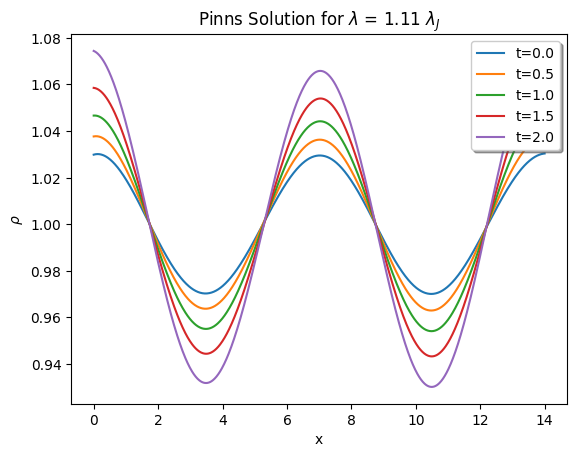

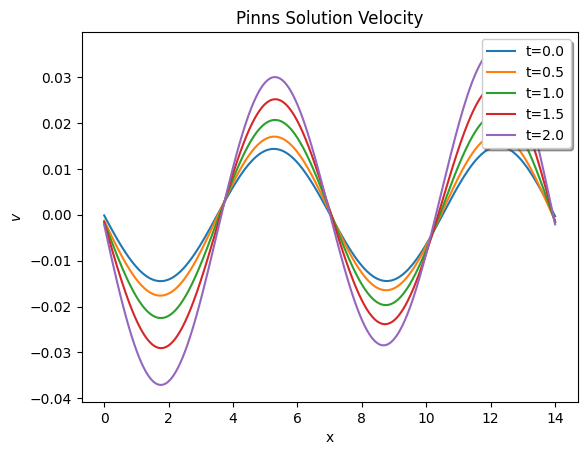

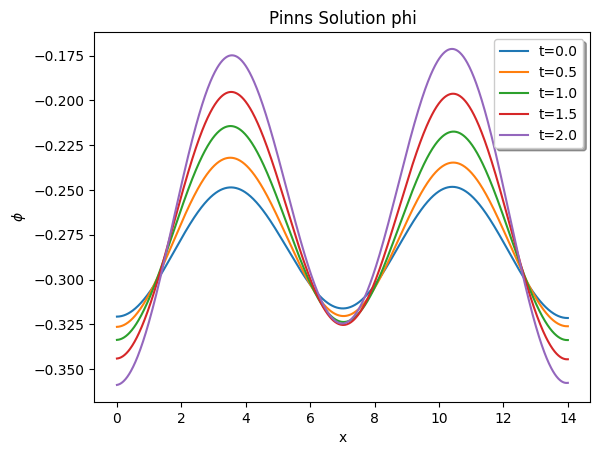

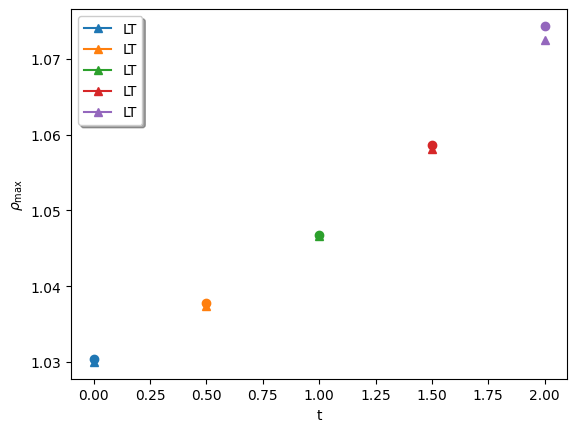

In [27]:
#import Plotting as pt
time_array = np.linspace(0,int(tmax),int(tmax)+3)
initial_params = xmin,xmax,rho_1, alpha ,lam,tmax ## required for plotting
plot_function(net,time_array,initial_params,velocity=True,isplot =True)

at time=  0.5
For dx = 0.014 and dt = 0.0028000000000000004 and time gridpoints n = 178 
Jean's Length 6.283185307179586
There is gravitational instabilty  lam = 7.0 > l_jean =6.283185307179586
at time=  1.5
For dx = 0.014 and dt = 0.0028000000000000004 and time gridpoints n = 535 
Jean's Length 6.283185307179586
There is gravitational instabilty  lam = 7.0 > l_jean =6.283185307179586


c:\Github\GRINN\GRINN_torch_code\LAX.py:213: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1,figsize=(6,4))
c:\Github\GRINN\GRINN_torch_code\LAX.py:224: UserWarning: Ignoring specified arguments in this call because figure with num: 2 already exists
  plt.figure(2,figsize=(6,4))
c:\Github\GRINN\GRINN_torch_code\LAX.py:237: UserWarning: Ignoring specified arguments in this call because figure with num: 3 already exists
  plt.figure(3,figsize=(6,4))
c:\Github\GRINN\GRINN_torch_code\LAX.py:247: UserWarning: Ignoring specified arguments in this call because figure with num: 4 already exists
  plt.figure(4,figsize=(6,4))


at time=  2.0
For dx = 0.014 and dt = 0.0028000000000000004 and time gridpoints n = 714 
Jean's Length 6.283185307179586
There is gravitational instabilty  lam = 7.0 > l_jean =6.283185307179586


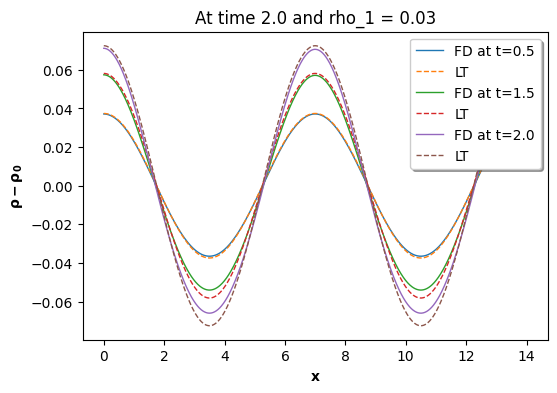

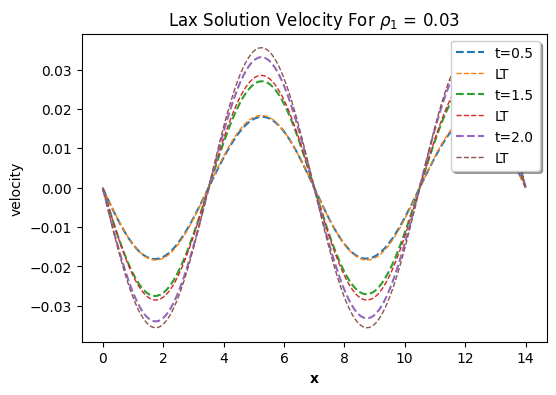

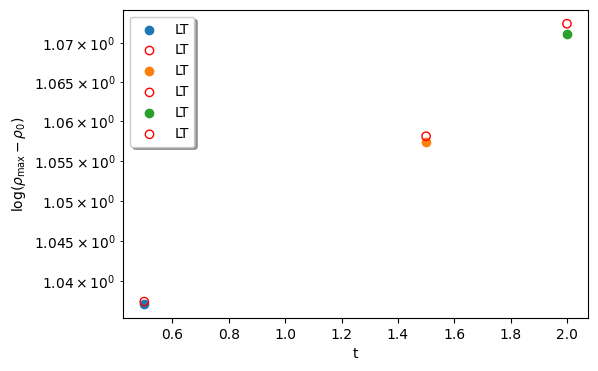

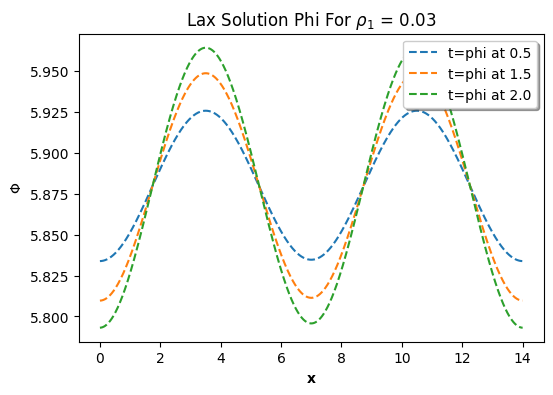

In [ ]:
import LAX as LAX
import numpy as np

## Parameters for the LAX method    
nu = 0.5            # COURANT number
N = 1000            # number of grid points

import time

# start = time.time()
# # t = 1          # time till integrate
# # LAX.lax_solution1D(t,N,nu,lam,num_of_waves,rho_1,gravity=True,isplot = True,comparison = True)
# end = time.time()
# print("Total time = {} sec for N= {}".format(end - start,N))


time_array = np.asarray([0.5,1.5,tmax])
for time_ in time_array:
    LAX.lax_solution1D(time_,N,nu,lam,num_of_waves,rho_1,gravity=True,isplot = True,comparison = True,animation=None)

at time=  0.5
For dx = 0.014 and dt = 0.0028000000000000004 and time gridpoints n = 178 
Jean's Length 6.283185307179586
There is gravitational instabilty  lam = 7.0 > l_jean =6.283185307179586
Plotting at t= 0.5
(1000, 1)
at time=  1.5
For dx = 0.014 and dt = 0.0028000000000000004 and time gridpoints n = 535 
Jean's Length 6.283185307179586
There is gravitational instabilty  lam = 7.0 > l_jean =6.283185307179586


C:\Users\tirth\AppData\Local\Temp\ipykernel_189060\4058648657.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0][2].legend(loc='best',fancybox=False, shadow=False, ncol=3,fontsize = 10)
C:\Users\tirth\AppData\Local\Temp\ipykernel_189060\4058648657.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1][2].legend(loc='best',fancybox=False, shadow=False, ncol=3,fontsize = 10)
C:\Users\tirth\AppData\Local\Temp\ipykernel_189060\4058648657.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2][2].legend(loc='best',fancybox=False, shadow=False, ncol=3,fontsize = 10)
C:\Users\tirth\AppData\Local\Temp\

Plotting at t= 1.5
(1000, 1)
at time=  2.5
For dx = 0.014 and dt = 0.0028000000000000004 and time gridpoints n = 892 
Jean's Length 6.283185307179586
There is gravitational instabilty  lam = 7.0 > l_jean =6.283185307179586
Plotting at t= 2.5
(1000, 1)


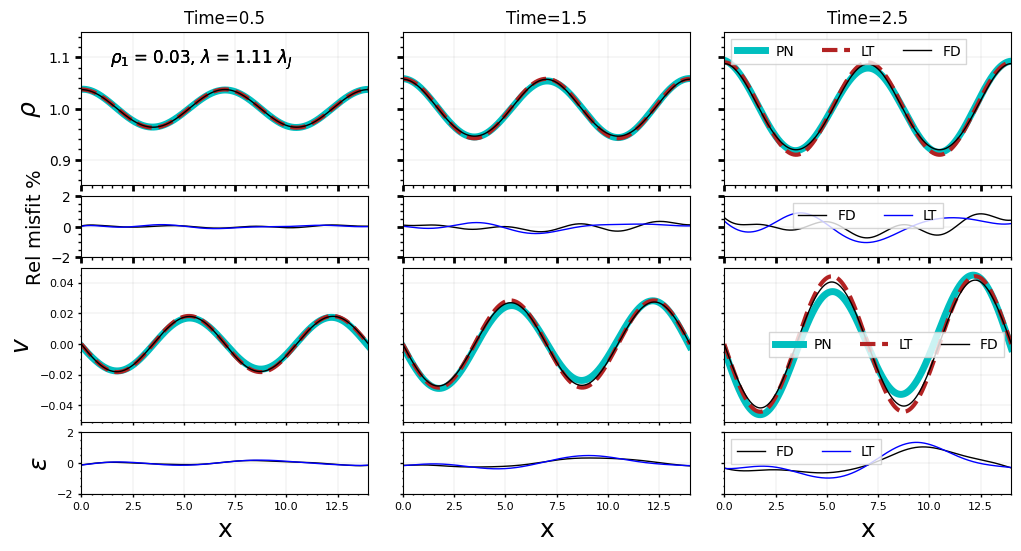

In [30]:
plt.style.use('default')
plt.rc('grid', linestyle='-', color='black', linewidth=0.05)
time_array = np.asarray([0.5, 1.5, 2.5])
fig, axes = plt.subplots(4, 3, sharex=True,  sharey='row',figsize=(12,6),gridspec_kw={'width_ratios':[1,1,1], 'height_ratios':[3,1.2,3,1.2]})
plt.subplots_adjust(wspace=0.12, hspace=0.1)
initial_params = xmin,xmax,rho_1, alpha ,lam,tmax ## Params for pl
for time,j in zip(time_array,range(3)):
    
    x,rho,v,phi,n,rho_LT,rho_LT_max,rho_max,v_LT= LAX.lax_solution1D(time,N,nu,lam,num_of_waves,rho_1,gravity=True,isplot = False,comparison = True)
    X,rho_pred0,v_pred0,phi_pred0,rho_max_PN,rho_theory = plot_function(net,time,initial_params,velocity=True,isplot = False, animation=True)
    axes[0][j].plot(X,rho_pred0,color='c',linewidth=5,label="PN")    
    axes[0][j].plot(x,rho_LT,linestyle='dashed',color ='firebrick',linewidth=3,label="LT")
    axes[0][j].plot(x,rho,linestyle='solid',color = 'black',linewidth=1.0,label="FD")
    axes[0][j].set_xlim(xmin,xmax)
    
    axes[0][j].set_title("Time={}".format(round(time,2)))
    axes[0][0].set_ylabel(r"$\rho$",fontsize = 18)
    # axes[0][j].set_xlabel("x",fontsize = 18)
    axes[0][j].grid("True")
    axes[0][j].minorticks_on()
    axes[0][j].tick_params(labelsize=10)
    axes[0][j].tick_params(axis='both', which='major',length=4, width=2)
    axes[0][j].tick_params(axis='both', which='minor',length=2, width=1)
    limu = 1.15*rho_o
    liml = .85*rho_o
    axes[0][j].set_ylim(liml,limu)
    axes[0][2].legend(loc='best',fancybox=False, shadow=False, ncol=3,fontsize = 10)
    axes[0][0].text(0.42, 0.82, r"$\rho_1$ = {}, $\lambda$ = {} $\lambda_J$ ".format(rho_1,round(lam/(2*np.pi),2)),fontsize = 12, horizontalalignment='center', verticalalignment='center', transform=axes[0][0].transAxes) 

    
    axes[1][j].plot(X,(rho_pred0[:,0]- rho)/((rho_pred0[:,0]+ rho)/2)*100,color = 'black',linewidth=1,label="FD")
    # axes[1][j].plot(x,(rho_pred0.flatten()-rho_LT.flatten())/((rho_pred0.flatten()+ rho_LT.flatten())/2)*100,color = 'firebrick',linestyle='dashed',linewidth=1,label="LT")
    # axes[1][j].plot(x,(rho_pred0[:,0]- rho[n-1,:])/((rho_pred0[:,0]+ rho[n-1,:])/2)*100,color = 'k',linewidth=1,label="FD")
    axes[1][j].plot(X,(rho_pred0[:,0]-rho_LT)/((rho_pred0[:,0]+ rho_LT)/2)*100,color = 'b',linewidth=1,label="LT")
    axes[1][j].set_xlabel("x",fontsize = 18)
    axes[1][j].grid("True")
    axes[1][j].minorticks_on()
    axes[1][j].tick_params(labelsize=10)
    axes[1][j].tick_params(axis='both', which='major',length=4, width=2)
    axes[1][j].tick_params(axis='both', which='minor',length=2, width=1.)
    axes[1][2].legend(loc='best',fancybox=False, shadow=False, ncol=3,fontsize = 10)
    # axes[1][0].set_ylabel(r"$\rho_{PN}- \rho_{FD or LT}/(0.5 (\times\rho_{PN}+ \rho_{FD or LT}))$",fontsize = 10)
    axes[1][j].set_ylim(-2.0,2.0)
    axes[1][j].set_xlim(xmin,xmax)
    axes[1][0].set_ylabel(r"Rel misfit $\%$ ",fontsize = 14)
    
    
    ### VELOCITY PART ######
   
    axes[2][j].plot(X,v_pred0,color='c',linewidth=5,label="PN")    
    axes[2][j].plot(X,v_LT,linestyle='dashed',color ='firebrick',linewidth=3,label="LT")
    axes[2][j].plot(x,v,linestyle='solid',color = 'black',linewidth=1.0,label="FD")
    
    
    # axes[3][j].set_title("Time={}".format(round(time,2)))
    axes[2][0].set_ylabel(r"$v$",fontsize = 18)
    # axes[0][j].set_xlabel("x",fontsize = 18)
    axes[2][j].grid("True")
    axes[2][j].minorticks_on()
    axes[2][j].tick_params(labelsize=8)
    axes[2][j].tick_params(axis='both', which='major',length=2, width=1)
    axes[2][j].tick_params(axis='both', which='minor',length=1, width=1)
    limu = 1.2*v_1
    liml = .8*v_1
    # axes[0][j].set_ylim(liml,limu)
    axes[2][2].legend(loc='best',fancybox=False, shadow=False, ncol=3,fontsize = 10)
    
#     axes[2][j].set_xlim(xmin,xmax)
#     axes[2][j].set_ylim(-0.6,0.6)
    
    
    axes[3][j].plot(x,(v_pred0[:,0]+1- (v+1))/((v_pred0[:,0]+1+ v+1)/2)*100,color = 'black',linewidth=1,label="FD")
    axes[3][j].plot(x,(v_pred0[:,0]+1- (v_LT+1))/((v_pred0[:,0]+1+ (v_LT+1))/2)*100,color = 'b',linewidth=1,label="LT")
    axes[3][j].set_xlabel("x",fontsize = 18)
    axes[3][j].grid("True")
    axes[3][j].minorticks_on()
    axes[3][j].tick_params(labelsize=8)
    axes[3][j].tick_params(axis='both', which='major',length=2, width=1)
    axes[3][j].tick_params(axis='both', which='minor',length=1, width=1.)
    axes[3][2].legend(loc='best',fancybox=False, shadow=False, ncol=3,fontsize = 10)
    # axes[1][0].set_ylabel(r"$\rho_{PN}- \rho_{FD or LT}/(0.5 (\times\rho_{PN}+ \rho_{FD or LT}))$",fontsize = 10)
    axes[3][0].set_ylabel(r"$\epsilon$ ",fontsize = 18)
    axes[3][j].set_ylim(-2,2)
    axes[3][j].set_xlim(xmin,xmax)
    
    
plt.savefig(output_folder+'/complete'+str(lam)+'_'+str(num_of_waves)+'_'+str(tmax)+'.png', dpi=500,bbox_inches = 'tight')

# plt.show()
 